In [ ]:
import dataset
import numpy as np
import matplotlib.pyplot as plt
# mydataset = dataset.generate_ks_dataset(100,save=True)
testdataset = dataset.KSDataset()


In [3]:
1

1

In [4]:
import torch
torch.cuda.memory_allocated() / 1024**3

0.7711954116821289

In [5]:
import dataset
import numpy as np

testdataset = dataset.KSDataset()
import PDFM_Copy1 as PDFM
# import PDFM
PDFlowMatching_class = PDFM.PDFlowMatching(testdataset)

In [ ]:

ckpt = torch.load('./saved_model/FM4discard_10000.pth', weights_only=True)
# ckpt = torch.load('./saved_model/KS_PDFM_degraded/KS_PDFM_degraded_8_1p37.pth', weights_only=True)# KS_PDFM_degraded_1_0p79 
PDFlowMatching_class.model.load_state_dict(ckpt)

ckpt = torch.load('./saved_model/pmodeltest.pth', weights_only=True)
PDFlowMatching_class.model_p.load_state_dict(ckpt)

### Evaluation on Constraint Satisfaction

In [ ]:
res = PDFlowMatching_class.sampler(2000)

resnp = testdataset.denorm(res.cpu().numpy())
# resnp = testdataset.denorm(testdataset[:20000,0,:,:].cpu().numpy())[:,None,:,:]

In [ ]:
test_num = 10
batch_size = 2000
feasible_record = np.zeros(test_num)
avg_delta_record = np.zeros(test_num)
for i in range(test_num):
    print(i)
    res = PDFlowMatching_class.sampler(batch_size)
    resnp = testdataset.denorm(res.cpu().numpy())
    residual = dataset.ks_batch_residual_Ln(resnp[:,0,:,:])/(63*64)
    feasible_num = np.sum(residual<0.033)
    feasible_record[i] = feasible_num/batch_size
    avg_delta_record[i] = np.mean(residual)

In [ ]:
print(np.mean(feasible_record))
print(np.std(feasible_record))

print(np.mean(avg_delta_record))
print(np.std(avg_delta_record))

### Visualization

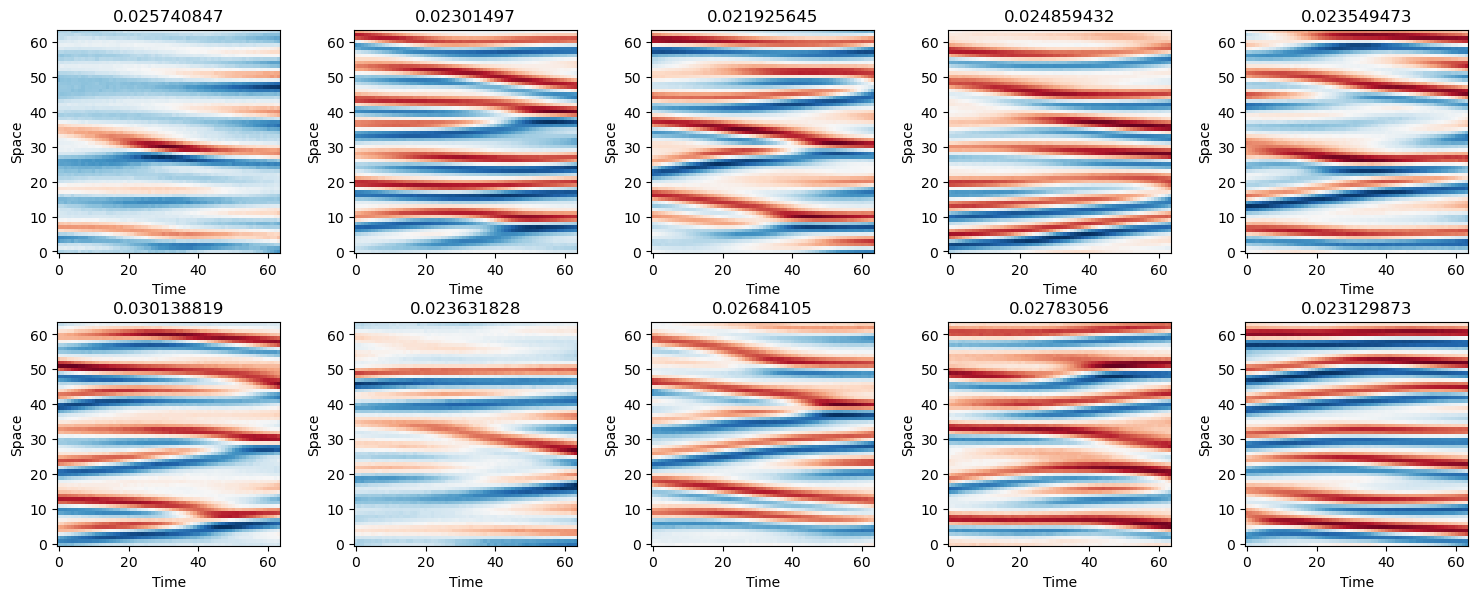

In [144]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

original_show = plt.show
plt.show = lambda *args, **kwargs: None

try:
    for i in range(10):
        j = i+10
        plt.sca(axes.flat[i])
        dataset.ks_show(resnp[j, 0])
        # plt.title(str(residual[j])+','+str(prob_test(resnp[j, 0], 1)))
        plt.title(str(residual[j]))
finally:
    plt.show = original_show

plt.tight_layout()
# plt.savefig('./figs/FMsamples.png', dpi=200, bbox_inches="tight")
plt.show()



In [27]:
import dataset
import numpy as np
import matplotlib.pyplot as plt
# mydataset = dataset.generate_ks_dataset(100,save=True)
testdataset = dataset.KSDataset(degrade_interval=(8,1))
testdataset_clean = dataset.KSDataset(degrade_interval=None)
# testdataset = dataset.KSDataset()

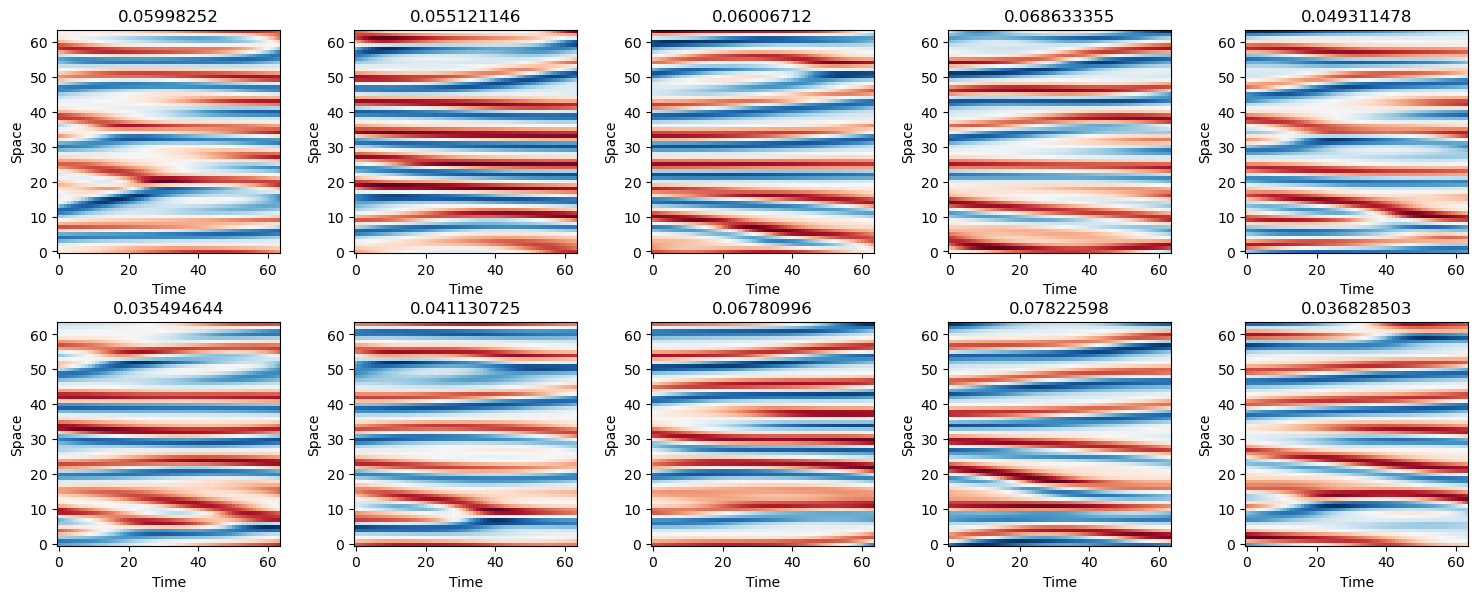

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

original_show = plt.show
plt.show = lambda *args, **kwargs: None

residual = dataset.ks_batch_residual_Ln(testdata)/(63*64)

try:
    for i in range(10):
        j = i+10
        plt.sca(axes.flat[i])
        dataset.ks_show(testdata[j])
        # plt.title(str(residual[j])+','+str(prob_test(resnp[j, 0], 1)))
        plt.title(str(residual[j]))
finally:
    plt.show = original_show

plt.tight_layout()
plt.savefig('./figs/FMsamples.png', dpi=200, bbox_inches="tight")
plt.show()



## Histogram error plots


In [15]:
import numpy as np
import matplotlib.pyplot as plt


def plot_ks_summary_histograms(
    u,
    dt,
    dx,
    bins=120,
    ranges=None,
    hide_tick=True,
    save_name=None,
):
    """
    u: array of shape (Nt, Nx) or (B, Nt, Nx)
    ranges: dict or None
        Optional ranges for stats, e.g.
        {
            "ut": (ut_min, ut_max),
            "ux": (ux_min, ux_max),
            "uxx": (uxx_min, uxx_max),
        }
        If None, ranges are inferred automatically from the data.

    save_name: str or None
        If provided, saves:
            {save_name}_trajectory.png
            {save_name}_ut_vs_ux.png
            {save_name}_uxx_vs_ux.png
    """
    if u.ndim == 2:
        u = u[None, ...]

    ut = (u[:, 2:, :] - u[:, :-2, :]) / (2 * dt)
    u_mid = u[:, 1:-1, :]
    ux = (np.roll(u_mid, -1, axis=2) - np.roll(u_mid, 1, axis=2)) / (2 * dx)
    uxx = (np.roll(u_mid, -1, axis=2) - 2 * u_mid + np.roll(u_mid, 1, axis=2)) / (dx ** 2)

    ut = ut.ravel()
    ux = ux.ravel()
    uxx = uxx.ravel()

    if ranges is None:
        ranges = {}

    ut_range = ranges.get("ut", (ut.min(), ut.max()))
    ux_range = ranges.get("ux", (ux.min(), ux.max()))
    uxx_range = ranges.get("uxx", (uxx.min(), uxx.max()))

    H1, x1, y1 = np.histogram2d(
        ux, ut,
        bins=bins,
        range=[ux_range, ut_range],
        density=True,
    )

    H2, x2, y2 = np.histogram2d(
        ux, uxx,
        bins=bins,
        range=[ux_range, uxx_range],
        density=True,
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    # axes[0].set_title("Sampled trajectory") 
    # axes[0].set_xlabel("x") 
    # axes[0].set_ylabel("t")
    # axes[1].set_xlabel(r"$\partial u / \partial x$") 
    # axes[1].set_ylabel(r"$\partial u / \partial t$") 
    # axes[1].set_title(r"$u_t$ vs $u_x$")
    # axes[2].set_xlabel(r"$\partial u / \partial x$") 
    # axes[2].set_ylabel(r"$\partial^2 u / \partial x^2$") 
    # axes[2].set_title(r"$u_{xx}$ vs $u_x$")
    axes[0].imshow(u[0], aspect="auto", origin="lower", cmap='RdBu')

    axes[1].imshow(
        np.log1p(H1.T),
        origin="lower",
        aspect="auto",
        extent=[x1[0], x1[-1], y1[0], y1[-1]],
    )

    axes[2].imshow(
        np.log1p(H2.T),
        origin="lower",
        aspect="auto",
        extent=[x2[0], x2[-1], y2[0], y2[-1]],
    )

    if hide_tick:
        for ax in axes:
            ax.set_xticks([])
            ax.set_yticks([])

    for ax in axes:
        ax.set_box_aspect(1)

    if save_name is not None:
        panels = [
            (u[0], None, f"{save_name}_trajectory.png"),
            (np.log1p(H1.T), [x1[0], x1[-1], y1[0], y1[-1]], f"{save_name}_ut_vs_ux.png"),
            (np.log1p(H2.T), [x2[0], x2[-1], y2[0], y2[-1]], f"{save_name}_uxx_vs_ux.png"),
        ]

        for img, extent, path in panels:
            fig_i, ax_i = plt.subplots(figsize=(4, 4))
            if extent is None:
                ax_i.imshow(img, aspect="auto", origin="lower", cmap='RdBu')
            else:
                ax_i.imshow(
                    img,
                    aspect="auto",
                    origin="lower",
                    extent=extent,
                )
            if hide_tick:
                ax_i.set_xticks([])
                ax_i.set_yticks([])
            ax_i.set_box_aspect(1)
            fig_i.savefig(path, dpi=300, bbox_inches="tight")
            plt.close(fig_i)

    return fig, axes, (H1, x1, y1), (H2, x2, y2)

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def plot_ks_summary_histograms(
    u,
    dt,
    dx,
    bins=120,
    ranges=None,
    hide_tick=True,
    save_name=None,
):
    """
    u: array of shape (Nt, Nx) or (B, Nt, Nx)
    ranges: dict or None
        Optional ranges for stats, e.g.
        {
            "ut": (ut_min, ut_max),
            "ux": (ux_min, ux_max),
            "uxx": (uxx_min, uxx_max),
        }
        If None, ranges are inferred automatically from the data.

    save_name: str or None
        If provided, saves:
            {save_name}_trajectory.png
            {save_name}_ut_vs_ux.png
            {save_name}_uxx_vs_ux.png
    """
    if u.ndim == 2:
        u = u[None, ...]

    ut = (u[:, 2:, :] - u[:, :-2, :]) / (2 * dt)
    u_mid = u[:, 1:-1, :]
    ux = (np.roll(u_mid, -1, axis=2) - np.roll(u_mid, 1, axis=2)) / (2 * dx)
    uxx = (np.roll(u_mid, -1, axis=2) - 2 * u_mid + np.roll(u_mid, 1, axis=2)) / (dx ** 2)

    ut = ut.ravel()
    ux = ux.ravel()
    uxx = uxx.ravel()

    if ranges is None:
        ranges = {}

    ut_range = ranges.get("ut", (ut.min(), ut.max()))
    ux_range = ranges.get("ux", (ux.min(), ux.max()))
    uxx_range = ranges.get("uxx", (uxx.min(), uxx.max()))

    H1, x1, y1 = np.histogram2d(
        ux, ut,
        bins=bins,
        range=[ux_range, ut_range],
        density=True,
    )

    H2, x2, y2 = np.histogram2d(
        ux, uxx,
        bins=bins,
        range=[ux_range, uxx_range],
        density=True,
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    axes[0].imshow(u[0], aspect="auto", origin="lower", cmap='RdBu')

    axes[1].imshow(
        np.log1p(H1.T),
        origin="lower",
        aspect="auto",
        extent=[x1[0], x1[-1], y1[0], y1[-1]],
    )

    axes[2].imshow(
        np.log1p(H2.T),
        origin="lower",
        aspect="auto",
        extent=[x2[0], x2[-1], y2[0], y2[-1]],
    )

    if hide_tick:
        for ax in axes:
            ax.set_xticks([])
            ax.set_yticks([])

    for ax in axes:
        ax.set_box_aspect(1)

    if save_name is not None:
        panels = [
            (u[0], None, f"{save_name}_trajectory.png"),
            (np.log1p(H1.T), [x1[0], x1[-1], y1[0], y1[-1]], f"{save_name}_ut_vs_ux.png"),
            (np.log1p(H2.T), [x2[0], x2[-1], y2[0], y2[-1]], f"{save_name}_uxx_vs_ux.png"),
        ]

        for img, extent, path in panels:
            fig_i, ax_i = plt.subplots(figsize=(4, 4))
            if extent is None:
                ax_i.imshow(img, aspect="auto", origin="lower")
            else:
                ax_i.imshow(
                    img,
                    aspect="auto",
                    origin="lower",
                    extent=extent,
                )
            if hide_tick:
                ax_i.set_xticks([])
                ax_i.set_yticks([])
            ax_i.set_box_aspect(1)
            fig_i.savefig(path, dpi=300, bbox_inches="tight")
            plt.close(fig_i)

    return fig, axes, (H1, x1, y1), (H2, x2, y2)

In [17]:
testrange = {
    "ut": (-15, 10),
    "ux": (-0.5, 0.5),
    "uxx": (-3, 3),
}

In [ ]:
# testdataset = dataset.KSDataset(degrade_interval=(8,1))
testdataset = dataset.KSDataset()
tdataset = testdataset.denorm(testdataset[:5000,0,:,:].cpu().numpy())

tdataset.shape

In [ ]:
test_num = 10
batch_size = 2000
he1_record = np.zeros(test_num)
he2_record = np.zeros(test_num)
feasible_record = np.zeros(test_num)
avg_delta_record = np.zeros(test_num)

fig, axes, histtruth1, histtruth2 = plot_ks_summary_histograms(tdataset[0:2000], dt=0.2, dx=1,bins = 64,
                                                              ranges = testrange, save_name = "None")

for i in range(test_num):
    print(i)
    res = PDFlowMatching_class.sampler(batch_size)
    resnp = testdataset.denorm(res.cpu().numpy())


    residual = dataset.ks_batch_residual_Ln(resnp[:,0,:,:])/(63*64)
    feasible_num = np.sum(residual<0.05)
    feasible_record[i] = feasible_num/batch_size
    avg_delta_record[i] = np.mean(residual)

    fig, axes, hist1, hist2 = plot_ks_summary_histograms(resnp[:2000,0], dt=0.2, 
                                                         dx=1,bins = 64, ranges = testrange, save_name = None)
    he1_record[i] = np.abs(histtruth1[0]-hist1[0]).sum()/(64*64)
    he2_record[i] = np.abs(histtruth2[0]-hist2[0]).sum()/(64*64)

    print(feasible_num/batch_size)
    print(np.mean(residual))
    print(np.abs(histtruth1[0]-hist1[0]).sum()/(64*64))
    print(np.abs(histtruth2[0]-hist2[0]).sum()/(64*64))

In [ ]:
print(np.mean(feasible_record))
print(np.std(feasible_record))

print(np.mean(avg_delta_record))
print(np.std(avg_delta_record))

print(np.mean(he1_record))
print(np.std(he1_record))

print(np.mean(he2_record))
print(np.std(he2_record))

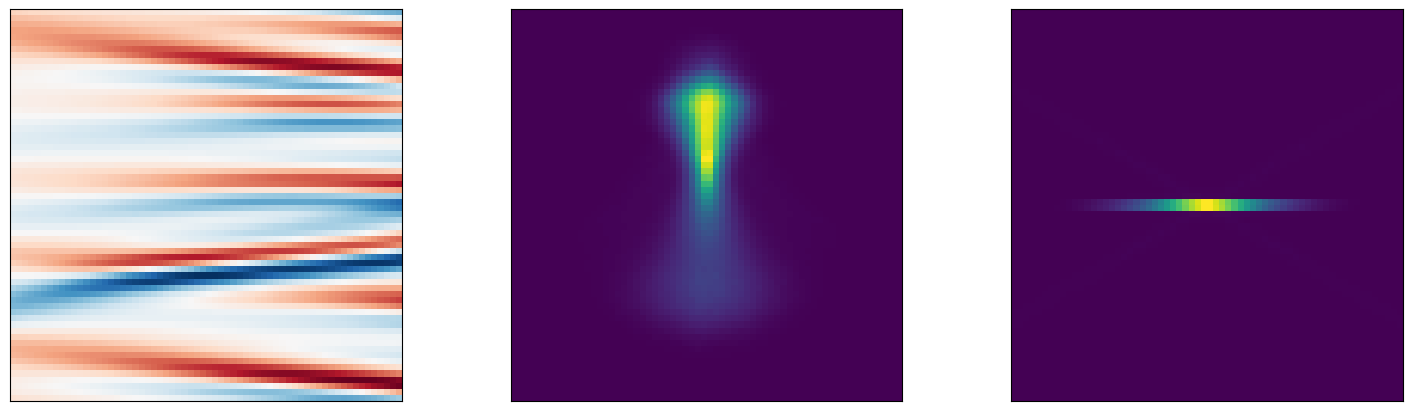

In [24]:
# rand

# fig, axes, histtruth1, histtruth2 = plot_ks_summary_histograms(tdataset[0:2000], dt=0.2, dx=1,bins = 64,
#                                                               ranges = testrange, save_name = "./figs/d_batch")
fig, axes, histtruth1, histtruth2 = plot_ks_summary_histograms(tdataset[0:2000], dt=0.2, dx=1,bins = 64,
                                                              ranges = testrange, save_name = "None")
plt.show()

In [ ]:
# fig, axes, histpd1, histpd2 = plot_ks_summary_histograms(resnp2[:1000,0], dt=0.2, 
                                                         # dx=1,bins = 64, ranges = testrange, save_name = "./figs/d_batch_pd")

fig, axes, histpd1, histpd2 = plot_ks_summary_histograms(resnp2[:2000,0], dt=0.2, 
                                                         dx=1,bins = 64, ranges = testrange, save_name = None)

plt.show()

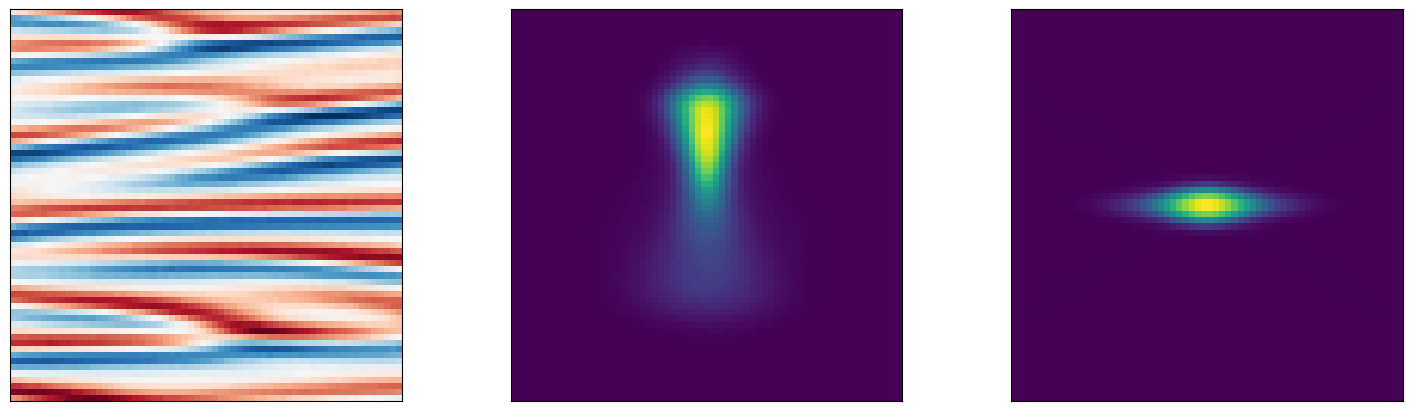

In [27]:
# fig, axes, histfm1, histfm2 = plot_ks_summary_histograms(resnp[:2000,0], dt=0.2, dx=1,bins = 64, ranges = testrange, save_name = "./figs/d_batch_fm")

fig, axes, histfm1, histfm2 = plot_ks_summary_histograms(resnp[:2000,0], dt=0.2, dx=1,bins = 64, ranges = testrange, save_name = None)
    
plt.show()

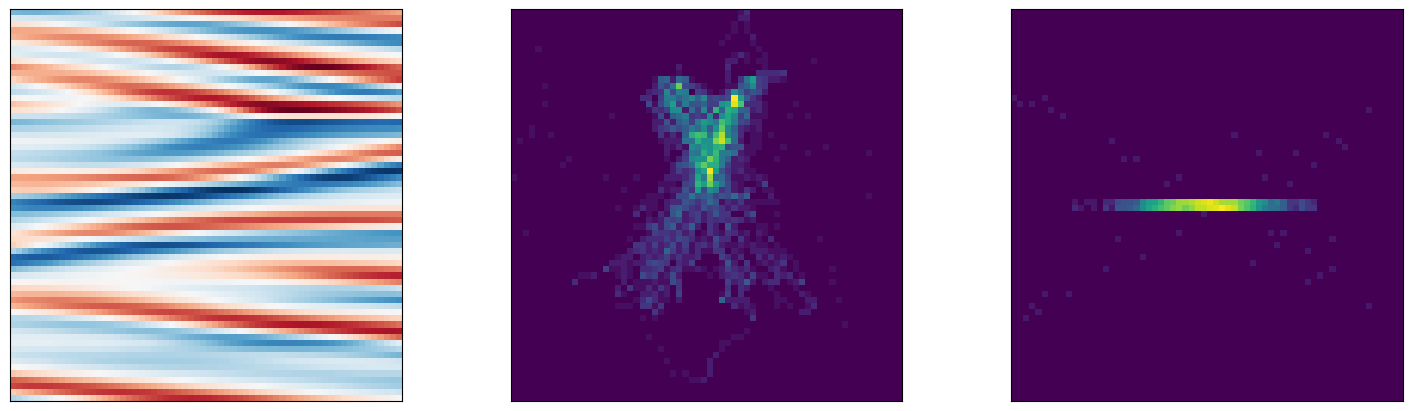

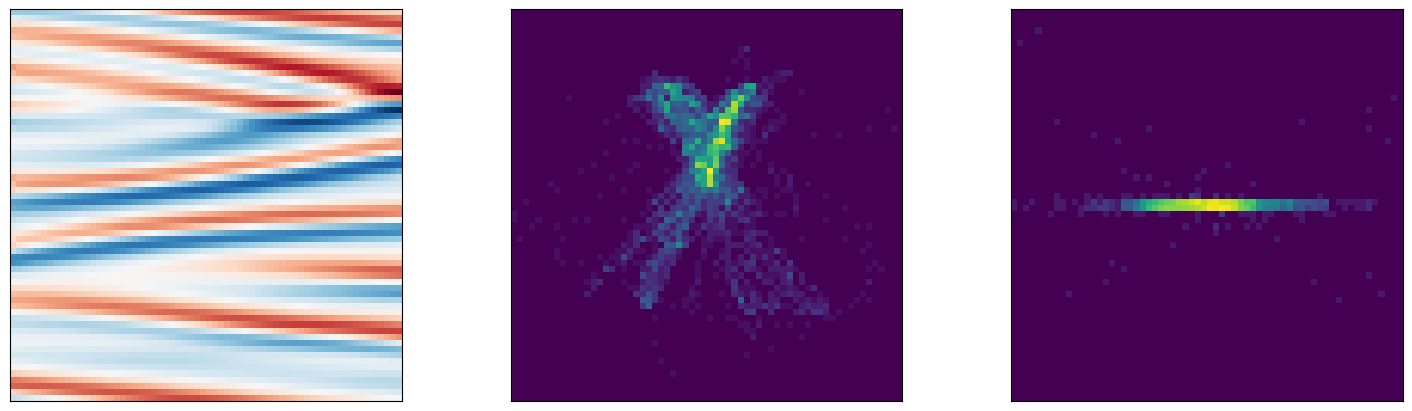

array([0.07336383], dtype=float32)

In [319]:
import exponax as ex
import jax.numpy as jnp
inp = resnp[1,0]

fig, axes, _, _ = plot_ks_summary_histograms(inp, dt=0.2, dx=1,bins = 64, ranges = testrange, save_name = "./figs/d_individual_fm1")

num_points = 64
horizon = 64-1
dt = 0.2

ks_stepper = ex.stepper.KuramotoSivashinskyConservative(
    num_spatial_dims=1, domain_extent=64.0,
    num_points=num_points, dt=dt,
    order=3
)


u_0 = jnp.asarray(inp[:,0])[None, :]


trajectory = ex.rollout(ks_stepper, horizon, include_init=True)(u_0)
fig, axes, _, _  = plot_ks_summary_histograms(trajectory[:,0,:].T, dt=0.2, dx=1,bins = 64, ranges = testrange, save_name = "./figs/d_individual_truth1")



plt.show()
dataset.ks_batch_residual_Ln(inp[None,:,:])/(63*64)

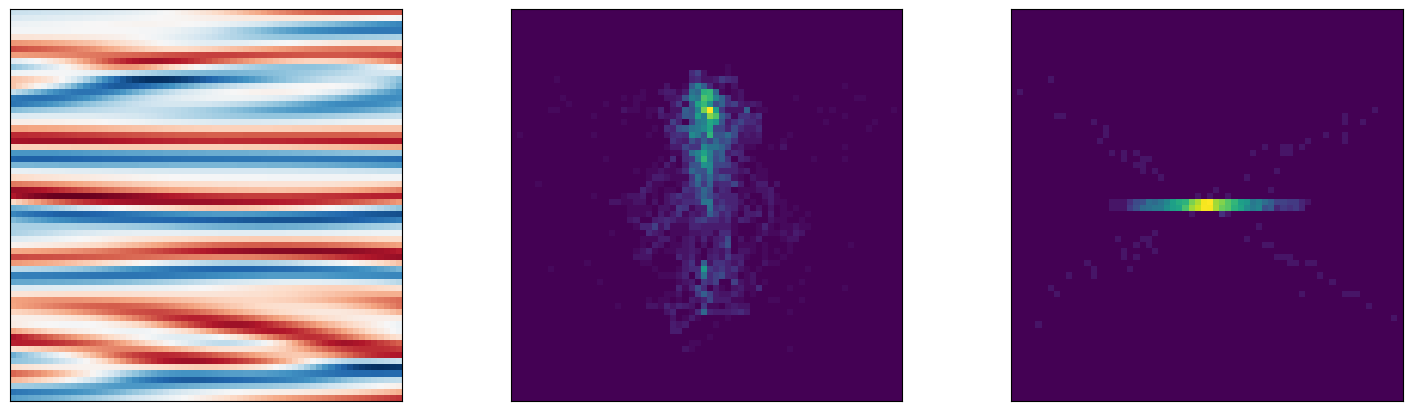

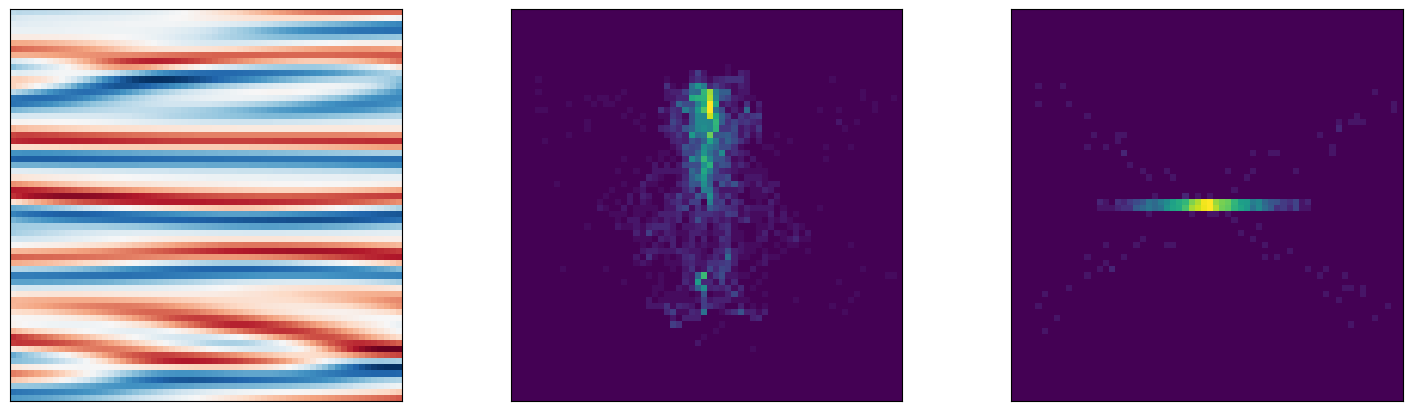

array([0.03549464], dtype=float32)

In [320]:
import exponax as ex
import jax.numpy as jnp
inp = resnp2[15,0]

fig, axes,_,_ = plot_ks_summary_histograms(inp, dt=0.2, dx=1,bins = 64, ranges = testrange, save_name = "./figs/d_individual_pd2")

plt.show()
# plt.show()

num_points = 64
horizon = 64-1
dt = 0.2

ks_stepper = ex.stepper.KuramotoSivashinskyConservative(
    num_spatial_dims=1, domain_extent=64.0,
    num_points=num_points, dt=dt,
    order=3
)


u_0 = jnp.asarray(inp[:,0])[None, :]


trajectory = ex.rollout(ks_stepper, horizon, include_init=True)(u_0)
fig, axes,_,_ = plot_ks_summary_histograms(trajectory[:,0,:].T, dt=0.2, dx=1,bins = 64, ranges = testrange, save_name = "./figs/d_individual_truth2")

# plt.show()
plt.show()
dataset.ks_batch_residual_Ln(inp[None,:,:])/(63*64)